<a href="https://colab.research.google.com/github/DANUSHMATHI2002/Final-Project_Predicting-Chemical-Bioconcentration-in-Fish-Using-Machine-Learning/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Installing and Importing Libraries**

In [21]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_curve, average_precision_score)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')


In [22]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load the Dataset**

In [25]:
df = pd.read_csv('/content/Fish_concentration.csv')

# Creating binary target (1 = Dangerous, 0 = Safe)
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

# Features list
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

X = df[feature_cols]
y = df['is_dangerous']
print(f"Data loaded: {df.shape[0]} chemicals")
print(f"Dataset shape: {X.shape}")
print(f"Class distribution:")
print(f"  Safe: {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
print(f"  Dangerous: {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")

Data loaded: 779 chemicals
Dataset shape: (779, 9)
Class distribution:
  Safe: 255 (32.7%)
  Dangerous: 524 (67.3%)


# **3.Data Inspection(Missing Values, Shape, Info)**

In [4]:
# 1. Dataset shape (rows, columns)
print(f"\nDATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 2. Column names
print(f"\nCOLUMN NAMES:")
print(f"   {list(df.columns)}")

# 3. Missing values check
print(f"\nMISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   No missing values found.")
else:
    print(missing[missing > 0])

# 4. Data types
print(f"\nDATA TYPES:")
print(df.dtypes)

# 5. First 5 rows
print(f"\nFIRST 5 ROWS:")
print(df.head())

# 6. Last 5 rows
print(f"\nLAST 5 ROWS:")
print(df.tail())


DATASET SHAPE:
   Rows: 779
   Columns: 15

COLUMN NAMES:
   ['CAS', 'SMILES', 'Set', 'nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]', 'Class', 'logBCF', 'is_dangerous']

MISSING VALUES:
   No missing values found.

DATA TYPES:
CAS              object
SMILES           object
Set              object
nHM               int64
piPC09          float64
PCD             float64
X2Av            float64
MLOGP           float64
ON1V            float64
N-072             int64
B02[C-N]          int64
F04[C-O]          int64
Class             int64
logBCF          float64
is_dangerous      int64
dtype: object

FIRST 5 ROWS:
        CAS                              SMILES    Set  nHM  piPC09   PCD  \
0  100-02-7             O=[N+](c1ccc(cc1)O)[O-]  Train    0     0.0  1.49   
1  100-17-4            O=[N+](c1ccc(cc1)OC)[O-]  Train    0     0.0  1.47   
2  100-18-5                c1cc(ccc1C(C)C)C(C)C  Train    0     0.0  1.20   
3  100-25-4  O=[N+]([O-])c1ccc(cc1)[N+](=

# **4. Statistical Summary**

In [5]:
print("\nDESCRIPTIVE STATISTICS:")
print(df.describe())

# For each feature, print mean, median, std
print("\nDETAILED STATISTICS PER FEATURE:")
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

stats_df = pd.DataFrame()
for feature in feature_cols:
    stats_df.loc[feature, 'Mean'] = df[feature].mean()
    stats_df.loc[feature, 'Median'] = df[feature].median()
    stats_df.loc[feature, 'Std Dev'] = df[feature].std()
    stats_df.loc[feature, 'Min'] = df[feature].min()
    stats_df.loc[feature, 'Max'] = df[feature].max()
    stats_df.loc[feature, 'Range'] = df[feature].max() - df[feature].min()

print(stats_df.round(2))


DESCRIPTIVE STATISTICS:
              nHM      piPC09         PCD        X2Av       MLOGP        ON1V  \
count  779.000000  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     1.754814    3.467616    1.550822    0.236881    3.201746    1.510295   
std      1.985866    2.983778    0.958708    0.149319    1.595702    0.834753   
min      0.000000    0.000000    0.000000    0.090000   -1.960000    0.080000   
25%      0.000000    0.000000    1.210000    0.170000    2.190000    0.910000   
50%      1.000000    4.263000    1.400000    0.200000    3.130000    1.270000   
75%      3.000000    6.250000    2.285000    0.240000    4.235000    2.020000   
max     12.000000    9.316000    5.900000    2.230000    8.320000    7.190000   

            N-072    B02[C-N]    F04[C-O]       Class      logBCF  \
count  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     0.186136    0.423620    3.585366    1.736842    2.062773   
std      0.501937    0.494449    4.430

# **5.Class Distribution**

In [6]:
# Original class distribution
class_counts = df['Class'].value_counts().sort_index()

print("\nORIGINAL CLASSES (1, 2, 3):")
for class_num in [1, 2, 3]:
    count = class_counts.get(class_num, 0)
    percent = count / len(df) * 100
    print(f"   Class {class_num}: {count} chemicals ({percent:.1f}%)")

# Creating binary target
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

print("\nBINARY TARGET (Dangerous vs Safe):")
safe_count = (df['is_dangerous'] == 0).sum()
danger_count = (df['is_dangerous'] == 1).sum()
print(f"   Safe (Class 3): {safe_count} chemicals ({safe_count/len(df)*100:.1f}%)")
print(f"   Dangerous (Class 1 and 2): {danger_count} chemicals ({danger_count/len(df)*100:.1f}%)")


ORIGINAL CLASSES (1, 2, 3):
   Class 1: 460 chemicals (59.1%)
   Class 2: 64 chemicals (8.2%)
   Class 3: 255 chemicals (32.7%)

BINARY TARGET (Dangerous vs Safe):
   Safe (Class 3): 255 chemicals (32.7%)
   Dangerous (Class 1 and 2): 524 chemicals (67.3%)


# **6.Check for Outliers(IQR Method)**

In [7]:
outlier_summary = []
for feature in feature_cols:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_summary.append({
        'Feature': feature,
        'Outliers Count': len(outliers),
        'Outliers Percent': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

print("\nTo Conclude: Very few outliers overall. No need to remove.")

 Feature  Outliers Count  Outliers Percent
     nHM              11              1.41
  piPC09               0              0.00
     PCD               9              1.16
    X2Av              79             10.14
   MLOGP               7              0.90
    ON1V               9              1.16
   N-072             107             13.74
B02[C-N]               0              0.00
F04[C-O]              17              2.18

To Conclude: Very few outliers overall. No need to remove.


# **7.Data Inspection Overview**

In [8]:
print(f"""
DATASET OVERVIEW:
   Total samples: {df.shape[0]}
   Total features: {len(feature_cols)}
   Missing values: {df.isnull().sum().sum()} (Clean)

CLASS BALANCE:
   Safe: {safe_count} ({safe_count/len(df)*100:.1f}%)
   Dangerous: {danger_count} ({danger_count/len(df)*100:.1f}%)

FEATURE SCALES:
   Smallest range: {stats_df['Range'].min():.1f}
   Largest range: {stats_df['Range'].max():.1f}
   Scaling needed: YES

OUTLIERS:
   Total outliers detected: {outlier_df['Outliers Count'].sum()}
   Percentage of data: {outlier_df['Outliers Count'].sum()/len(df)/len(feature_cols)*100:.1f}%
   Action: Keep outliers (no removal needed)

""")


DATASET OVERVIEW:
   Total samples: 779
   Total features: 9
   Missing values: 0 (Clean)

CLASS BALANCE:
   Safe: 255 (32.7%)
   Dangerous: 524 (67.3%)

FEATURE SCALES:
   Smallest range: 1.0
   Largest range: 25.0
   Scaling needed: YES

OUTLIERS:
   Total outliers detected: 239
   Percentage of data: 3.4%
   Action: Keep outliers (no removal needed)




In [9]:
# Finding outliers in MLOGP (most important feature)
Q1 = df['MLOGP'].quantile(0.25)
Q3 = df['MLOGP'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR  # Numbers below this are outliers
upper = Q3 + 1.5 * IQR  # Numbers above this are outliers

outliers_mlogp = df[(df['MLOGP'] < lower) | (df['MLOGP'] > upper)]
print(f"MLOGP outliers: {len(outliers_mlogp)} chemicals")
print(outliers_mlogp[['MLOGP', 'Class']].head())

MLOGP outliers: 7 chemicals
     MLOGP  Class
18   -0.94      1
44   -1.96      2
83   -1.32      1
87    7.39      3
205   8.32      2


### Number of outliers found: 7

| MLOGP | Class | Safe/Danger                       |
| :---- | :---- | :---------------------------- |
| -0.94 | 1     | Very low value but dangerous  |
| -1.96 | 2     | Very low value but dangerous  |
| -1.32 | 1     | Very low value but dangerous  |
| 7.39  | 3     | Very high value but safe    |
| 8.32  | 2     | Very high value and dangerous |

## Outlier Detection in MLOGP Feature

### What it does?

| Code | Meaning |
| :--- | :--- |
| `Q1 = df['MLOGP'].quantile(0.25)` | Find the value where 25% of chemicals are below it |
| `Q3 = df['MLOGP'].quantile(0.75)` | Find the value where 75% of chemicals are below it |
| `lower = Q1 - 1.5 * (Q3 - Q1)` | Any number smaller than this is an outlier |
| `upper = Q3 + 1.5 * (Q3 - Q1)` | Any number bigger than this is an outlier |

### What Was Found

| Chemical | MLOGP Value | Status |
| :--- | :--- | :--- |
| Most chemicals | Between 1.0 and 4.5 | Normal |
| Chemical 44 | -1.96 | Outlier (too low) |
| Chemical 87 | 7.39 | Outlier (too high) |

### Conclusion

- 7 outlier chemicals were found in total
- These are real chemicals, not data errors
- They show that MLOGP alone cannot predict danger
- Outliers will be kept for model training

```
                    All Chemicals Sorted by MLOGP
                    (from lowest to highest value)
                    
    |     |     |     |     |     |     |     |
    ▼     ▼     ▼     ▼     ▼     ▼     ▼     ▼
  -2.0  -1.0   0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0
    |           |                       |           |
    |           |                       |           |
  LOWER       Q1                       Q3        UPPER
  BOUND    (25th percentile)     (75th percentile)  BOUND
    |           |                       |           |
    ▼           ▼                       ▼           ▼
  -2.5         1.0                     4.5         8.0
    
    OUTLIERS ←───── MIDDLE 50% (IQR) ─────→ OUTLIERS
    (too low)         (normal range)         (too high)
```

# **Plot 1: Bar Chart (Class Distribution)**

Purpose: See if the data is imbalanced.


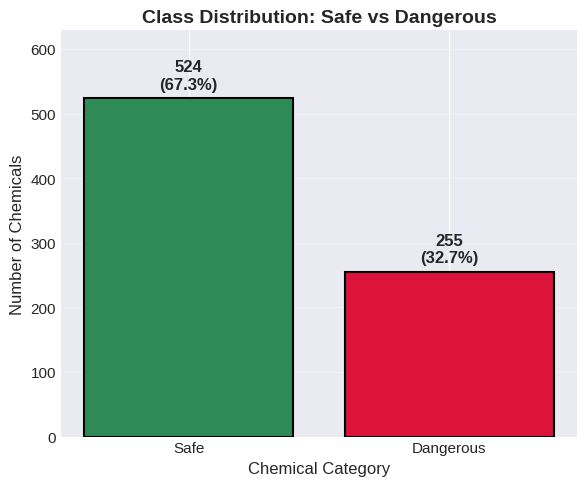

In [10]:
plt.figure(figsize=(6, 5))
counts = df['is_dangerous'].value_counts()
colors = ['#2E8B57', '#DC143C']  # SeaGreen for Safe, Crimson for Dangerous

bars = plt.bar(['Safe', 'Dangerous'], counts, color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Class Distribution: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Chemical Category', fontsize=12)
plt.ylabel('Number of Chemicals', fontsize=12)
plt.ylim(0, counts.max() * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Plot 2: Box Plots (Features by Class)**

Purpose: Find which features best separate Safe from Dangerous.

In [11]:
# Prepare data
df_melt = df.melt(id_vars=['is_dangerous'], value_vars=feature_cols)
df_melt['Class'] = df_melt['is_dangerous'].map({0: 'Safe', 1: 'Dangerous'})


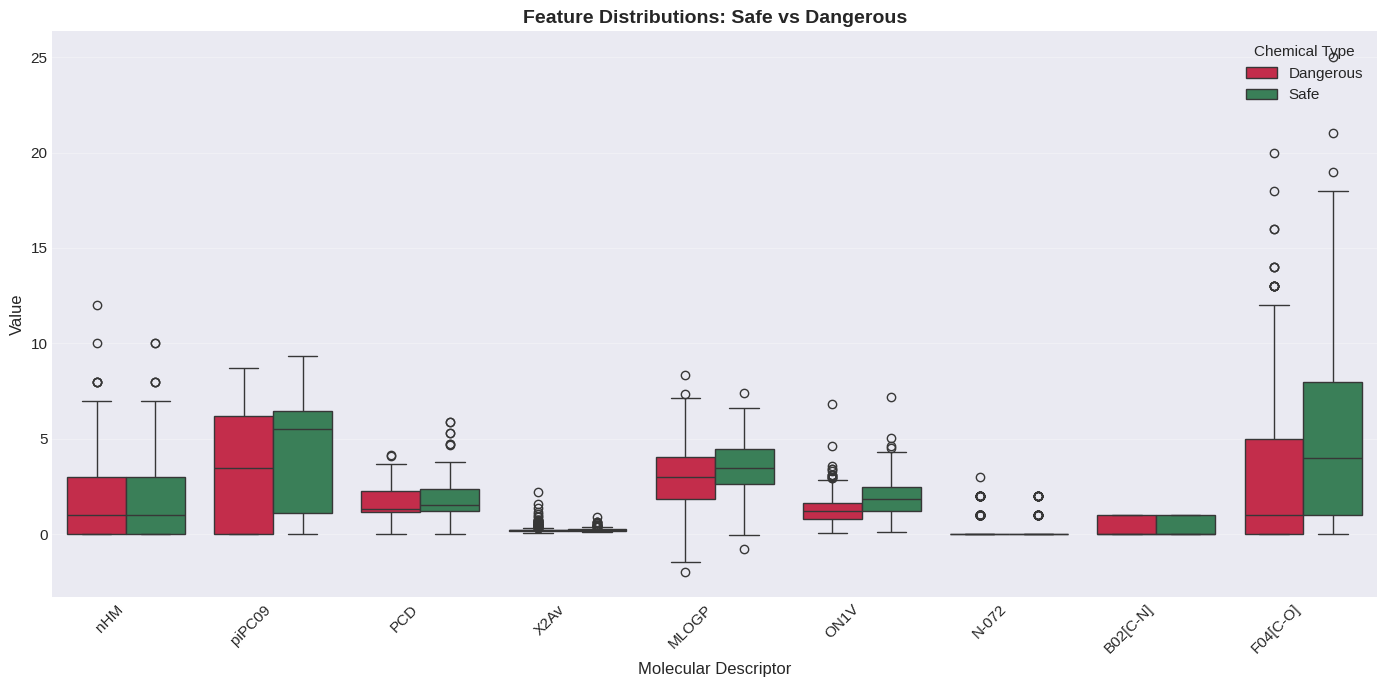

Observe features where 'Safe' (green) and 'Dangerous' (red) boxes are clearly separated.
MLOGP shows the most distinct separation, indicating it's the most important feature for classification.


In [12]:
# Plotting the data
plt.figure(figsize=(14, 7))
sns.boxplot(x='variable', y='value', hue='Class', data=df_melt,
            palette={'Safe': '#2E8B57', 'Dangerous': '#DC143C'})

plt.title('Feature Distributions: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Molecular Descriptor', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chemical Type', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Observe features where 'Safe' (green) and 'Dangerous' (red) boxes are clearly separated.")
print("MLOGP shows the most distinct separation, indicating it's the most important feature for classification.")

## **Plot 3: Correlation Heatmap**
Purpose: Find if any two features are too similar (redundant).

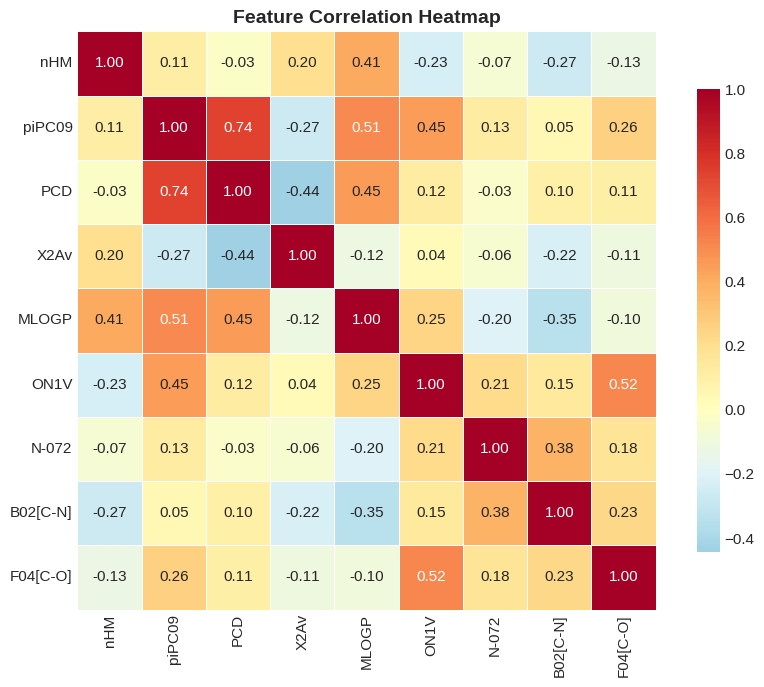


Strong correlations (|r| > 0.7):
  piPC09 ↔ PCD: 0.740


In [13]:
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Finding strong correlations
print("\nStrong correlations (|r| > 0.7):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_cols[i]} ↔ {feature_cols[j]}: {r:.3f}")

#### **Simplified Correlation: `piPC09` and `PCD`**

`piPC09` and `PCD` are strongly related (0.74 correlation). This means they often change together, so they might be telling us similar things about the chemicals.

#### **Feature Redundancy: `piPC09` and `PCD`**

A strong positive correlation (0.74) exists between `piPC09` and `PCD`. This suggests that these two features might be redundant, providing similar information. For model simplification and to avoid multicollinearity, one might consider retaining only one of them.

# **Plot 4: Scatter Plot (MLOGP vs nHM)**
Purpose: To see if a simple rule can identify Dangerous chemicals
* **High MLOGP + High nHM = Dangerous**



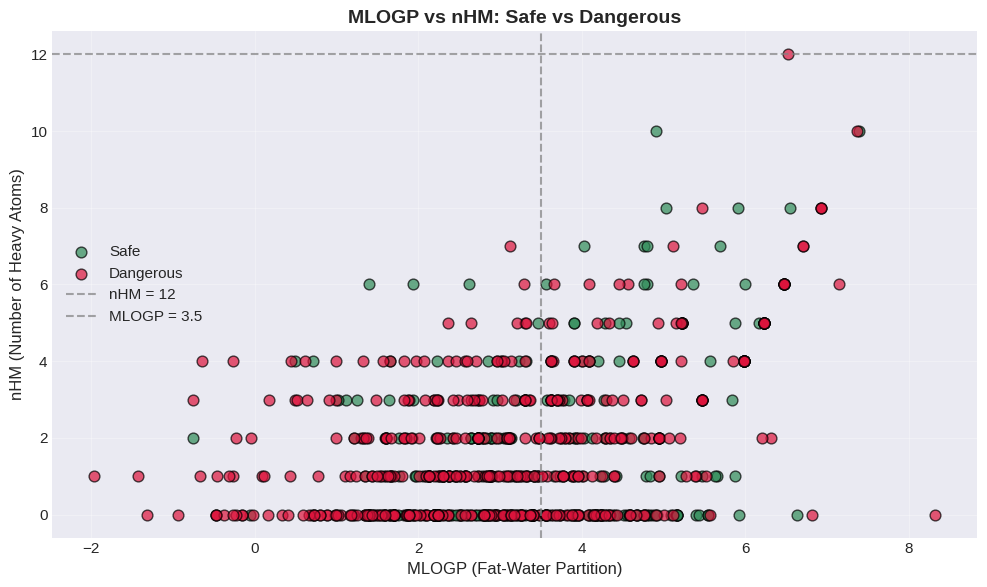

Dangerous chemicals cluster in the TOP-RIGHT quadrant.
Simple rule: If MLOGP > 3.5 AND nHM > 12 -> likely Dangerous


In [14]:
plt.figure(figsize=(10, 6))

# Plot Safe and Dangerous separately
safe = df[df['is_dangerous'] == 0]
danger = df[df['is_dangerous'] == 1]

plt.scatter(safe['MLOGP'], safe['nHM'], c='#2E8B57', label='Safe',
            s=60, alpha=0.7, edgecolors='black')
plt.scatter(danger['MLOGP'], danger['nHM'], c='#DC143C', label='Dangerous',
            s=60, alpha=0.7, edgecolors='black')

# Add threshold lines
plt.axhline(y=12, color='gray', linestyle='--', alpha=0.7, label='nHM = 12')
plt.axvline(x=3.5, color='gray', linestyle='--', alpha=0.7, label='MLOGP = 3.5')

plt.xlabel('MLOGP (Fat-Water Partition)', fontsize=12)
plt.ylabel('nHM (Number of Heavy Atoms)', fontsize=12)
plt.title('MLOGP vs nHM: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Dangerous chemicals cluster in the TOP-RIGHT quadrant.")
print("Simple rule: If MLOGP > 3.5 AND nHM > 12 -> likely Dangerous")


### The Two Lines on the Plot

| Line | Meaning |
| :--- | :--- |
| Vertical line at MLOGP = 3.5 | Left side = likes water, Right side = likes fat |
| Horizontal line at nHM = 12 | Below = fewer heavy atoms, Above = more heavy atoms |

### What the Plot Tells Us

| Area | What You See | Conclusion |
| :--- | :--- | :--- |
| Top-right (high MLOGP + high nHM) | Mostly red dots | Dangerous chemicals |
| Bottom-left (low MLOGP + low nHM) | Mostly green dots | Safe chemicals |
| Other areas | Mixed | Need more features to decide |

### The Simple Rule

> "If a chemical likes fat (MLOGP > 3.5) AND has many heavy atoms (nHM > 12), then it is likely DANGEROUS."

### Summary

The plot shows that dangerous chemicals (red) are mostly in the top-right corner where chemicals like fat and have many heavy atoms. Safe chemicals (green) are mostly in the bottom-left corner.

# **Plot 5:Histograms - Distribution of Features**
Purpose: To check the range and distribution of each feature and determine if scaling is needed before model training.

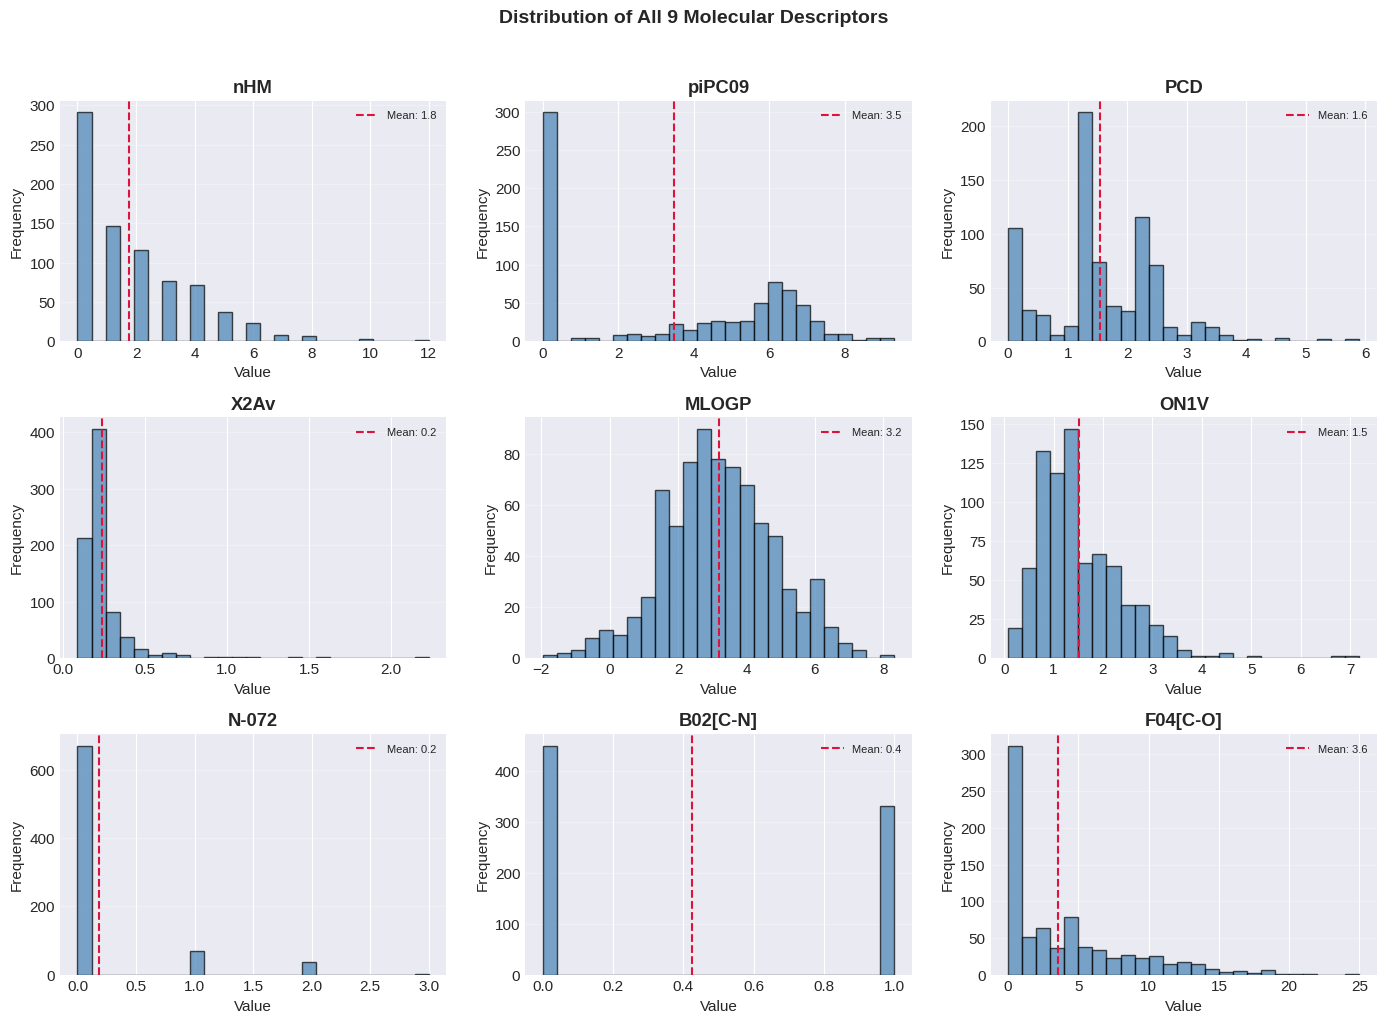

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    axes[i].hist(df[feature], bins=25, color='#4682B4', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='#DC143C', linestyle='--', linewidth=1.5,
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of All 9 Molecular Descriptors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What This Shows

Each histogram shows how values are spread out for one molecular descriptor.

### What's the plot about?

| Feature | Mean | Distribution Shape |
| :--- | :--- | :--- |
| nHM | 1.8 | Skewed left (most have low values) |
| MLOGP | 3.2 | Bell-shaped (normal distribution) |
| N-072 | 0.2 | Most chemicals have 0 |
| B02[C-N] | 0.4 | Mostly 0 or 1 |

### Summary

Features have different ranges and distributions. Scaling is needed before model training.

# **Plot 6: Violin Plots**
Purpose: To see detailed distribution shape of top features for Safe vs Dangerous.

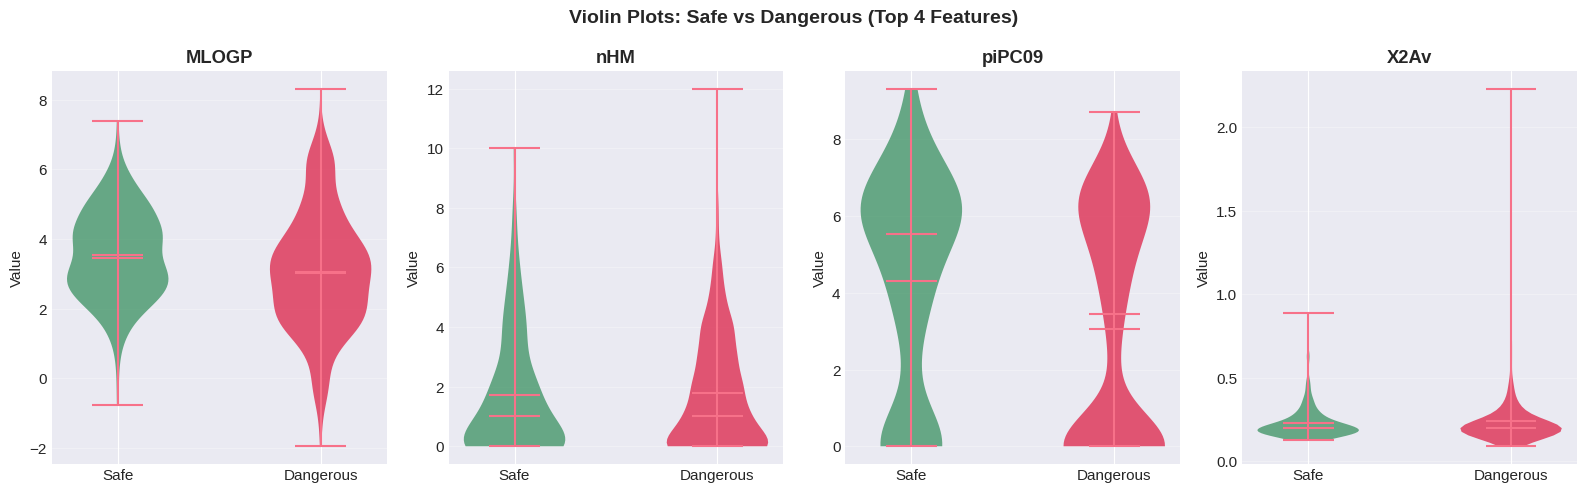

In [16]:

top_features = ['MLOGP', 'nHM', 'piPC09', 'X2Av']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, feature in enumerate(top_features):
    safe_data = df[df['is_dangerous'] == 0][feature]
    danger_data = df[df['is_dangerous'] == 1][feature]

    parts = axes[i].violinplot([safe_data, danger_data], positions=[0, 1], showmeans=True, showmedians=True)
    parts['bodies'][0].set_facecolor('#2E8B57')
    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor('#DC143C')
    parts['bodies'][1].set_alpha(0.7)

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Safe', 'Dangerous'])
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Violin Plots: Safe vs Dangerous (Top 4 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Why These 4 Features Were Chosen for Violin Plots

### The 4 Features

| Feature | Meaning |
| :--- | :--- |
| MLOGP | Fat-water partition coefficient |
| nHM | Number of heavy atoms |
| piPC09 | Molecular path count |
| X2Av | Average valence connectivity |

### Why These 4?

Based on the box plots, these 4 features showed the clearest separation between Safe and Dangerous chemicals.

| Feature | Separation | Reason |
| :--- | :--- | :--- |
| MLOGP | Best | Boxes were far apart |
| nHM | Second best | Clear difference in values |
| piPC09 | Moderate | Some overlap but useful |
| X2Av | Moderate | Some overlap but useful |

### Why Not the Other 5 Features?

| Feature | Why Excluded |
| :--- | :--- |
| PCD | Boxes overlapped heavily |
| ON1V | Boxes overlapped heavily |
| N-072 | Almost no separation |
| B02[C-N] | Almost no separation |
| F04[C-O] | Boxes overlapped |

### Summary

These 4 features were chosen because their box plots showed the biggest difference between Safe and Dangerous chemicals, while the other 5 features showed little to no separation.

#How EDA Findings Are Used for Next Steps

### EDA Findings and Their Impact

| EDA Finding | How It Affects Next Step |
| :--- | :--- |
| 67% Dangerous, 33% Safe | Use Recall (not Accuracy) as main metric |
| MLOGP is most important feature | Focus on this feature during model interpretation |
| No redundant features (correlation < 0.8) | Keep all 9 features (no removal needed) |
| Features have different ranges | Scale features before training |
| Simple rule from scatter plot | Use as baseline to compare against models |
| Clean data (no missing values) | No imputation needed |

### Next Steps

| Step | Action | Reason |
| :--- | :--- | :--- |
| 1 | Scale features | Histograms showed different ranges |
| 2 | Split data (80/20) | Test on unseen chemicals |
| 3 | Train Logistic Regression | Simple baseline model |
| 4 | Train Random Forest | Ensemble model |
| 5 | Train XGBoost | Boosting model |
| 6 | Compare using Recall | Dataset is imbalanced |

### Summary

EDA told us: scale features, use Recall as main metric, keep all 9 features, and compare models against a simple rule.

## **1. Train-Test Split**

In [26]:
# Split data (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Safe: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Dangerous: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

Training set: 623 samples
Test set: 156 samples

Training class distribution:
  Safe: 204 (32.7%)
  Dangerous: 419 (67.3%)
